In [230]:
import pandas as pd 
import seaborn as sns
import random
import numpy as np

In [231]:
import warnings
warnings.filterwarnings('ignore')

In [232]:
maindf = pd.read_csv('02-14-2018.csv')
random.seed(42)
random_indices = [random.randint(1, maindf.shape[0]) for _ in range(45000)]
print(random_indices)

[670488, 116740, 26226, 777573, 288390, 256788, 234054, 146317, 772247, 107474, 709571, 776647, 935519, 571859, 91162, 619177, 442418, 33327, 31245, 98247, 229259, 243963, 529904, 631263, 27825, 588509, 208497, 750801, 681454, 735393, 571413, 439899, 231149, 471030, 617890, 291705, 848750, 911528, 6815, 795668, 844963, 167415, 732053, 443144, 356779, 291370, 163033, 225773, 1003711, 800582, 352945, 107176, 97252, 398383, 101415, 376418, 888663, 360664, 633053, 277371, 846336, 45562, 765180, 481742, 562276, 130890, 1020386, 967097, 396923, 82628, 578857, 307420, 869694, 659177, 648565, 928464, 903566, 379202, 605398, 201630, 738798, 72934, 48051, 693385, 238969, 810621, 303446, 1033080, 83668, 896866, 244099, 908574, 105908, 398592, 291477, 475436, 666564, 874629, 382555, 170556, 388163, 372529, 219685, 702730, 279947, 735912, 982154, 716752, 679515, 74871, 638721, 665823, 179452, 560087, 764545, 256703, 171340, 484715, 397888, 283061, 1037591, 970343, 671089, 721591, 584005, 230284, 71

In [233]:
maindf = maindf.iloc[random_indices].reset_index(drop=True)
maindf = maindf.replace([np.inf, -np.inf], np.nan) 
maindf.fillna(0, inplace=True)
maindf.shape, maindf.columns

((45000, 80),
 Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
        'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
        'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
        'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
        'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
        'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
        'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
        'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
        'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
        'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
        'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
        'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
        'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
        'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ra

In [234]:
maindf['Label'].value_counts()

Label
Benign            28706
FTP-BruteForce     8379
SSH-Bruteforce     7915
Name: count, dtype: int64

In [235]:
maindf[:1]

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,14/02/2018 10:29:54,5920927,4,4,97,232,97,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [236]:
maindf['Idle Mean'] = maindf['Idle Mean'] / 1000000

In [237]:
maindf['Idle Mean'].max()

117.749936

In [238]:
maindf = maindf.fillna(0)

In [239]:
from sklearn.feature_selection import mutual_info_classif

y = maindf.pop('Label')
maindf.pop('Timestamp')
X = maindf

In [282]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = pd.Series(le.fit_transform(y))

In [283]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)
X

array([[-0.32815066, -0.47519716, -0.10562828, ..., -0.06555766,
        -0.22149121, -0.21440727],
       [-0.33227787, -0.47519716, -0.32720101, ..., -0.06555766,
        -0.22149121, -0.21440727],
       [-0.33227787, -0.47519716, -0.32720169, ..., -0.06555766,
        -0.22149121, -0.21440727],
       ...,
       [-0.33220792, -0.47519716, -0.3272015 , ..., -0.06555766,
        -0.22149121, -0.21440727],
       [ 3.15815304, -0.47519716, -0.32720172, ..., -0.06555766,
        -0.22149121, -0.21440727],
       [-0.30261792, -0.47519716, -0.28779038, ..., -0.06555766,
        -0.22149121, -0.21440727]])

In [284]:
X_df = pd.DataFrame(X, columns=maindf.columns)

In [285]:
X_df

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.328151,-0.475197,-0.105628,-0.045803,-0.030222,-0.362027,-0.028287,-0.282446,-0.437753,-0.290530,...,-0.345951,-0.293109,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
1,-0.332278,-0.475197,-0.327201,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,1.508988,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
2,-0.332278,-0.475197,-0.327202,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,1.508988,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
3,-0.330039,1.981179,-0.325096,-0.084933,-0.047587,-0.381570,-0.028455,-0.492120,1.627499,0.027183,...,-0.345951,-1.374367,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
4,-0.332208,-0.475197,-0.327201,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,0.788149,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,-0.330039,1.981179,-0.327152,-0.104498,-0.056269,-0.431001,-0.029109,-0.503156,1.472605,-0.033334,...,-0.541603,-1.374367,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
44996,-0.328151,-0.475197,-0.327198,-0.084933,-0.064952,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,-0.293109,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
44997,-0.332208,-0.475197,-0.327201,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,0.788149,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
44998,3.158153,-0.475197,-0.327202,-0.065368,-0.064952,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,-0.293109,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407


In [286]:
mi = mutual_info_classif(X, y)

In [287]:
mimi_df = pd.DataFrame({'Feature': X_df.columns, 'Mutual Information': mi}).sort_values(by='Mutual Information', ascending=False)

mimi_df

,Feature,Mutual Information
0,Dst Port,0.903181
69,Fwd Seg Size Min,0.891006
67,Init Bwd Win Byts,0.818170
2,Flow Duration,0.800367
38,Bwd Pkts/s,0.799967
...,...,...
32,Bwd PSH Flags,0.000000
34,Bwd URG Flags,0.000000
59,Bwd Byts/b Avg,0.000000
57,Fwd Pkts/b Avg,0.000000


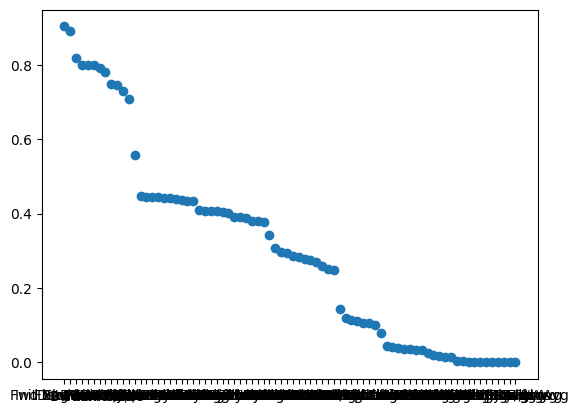

In [288]:
import matplotlib.pyplot as plt

plt.scatter(x=mimi_df['Feature'], y=mimi_df['Mutual Information'])
plt.show()

In [289]:
cls = mimi_df.apply(lambda x: x['Feature'] if x['Mutual Information'] > 0.02 else None, axis=1)
cls = cls.dropna().tolist()
X_df_new = X_df[cls]

In [290]:
clsorrelation_with_y = X_df_new.corrwith(y)


# plt.figure(figsize=(12, 10))
# clsorrelation_with_y.sort_values().plot(kind='barh', color='skyblue')
# plt.title('Correlation with Target Variable (y)', fontsize=16)
# plt.xlabel('Correlation Coefficient', fontsize=12)
# plt.ylabel('Features', fontsize=12)
# plt.show()

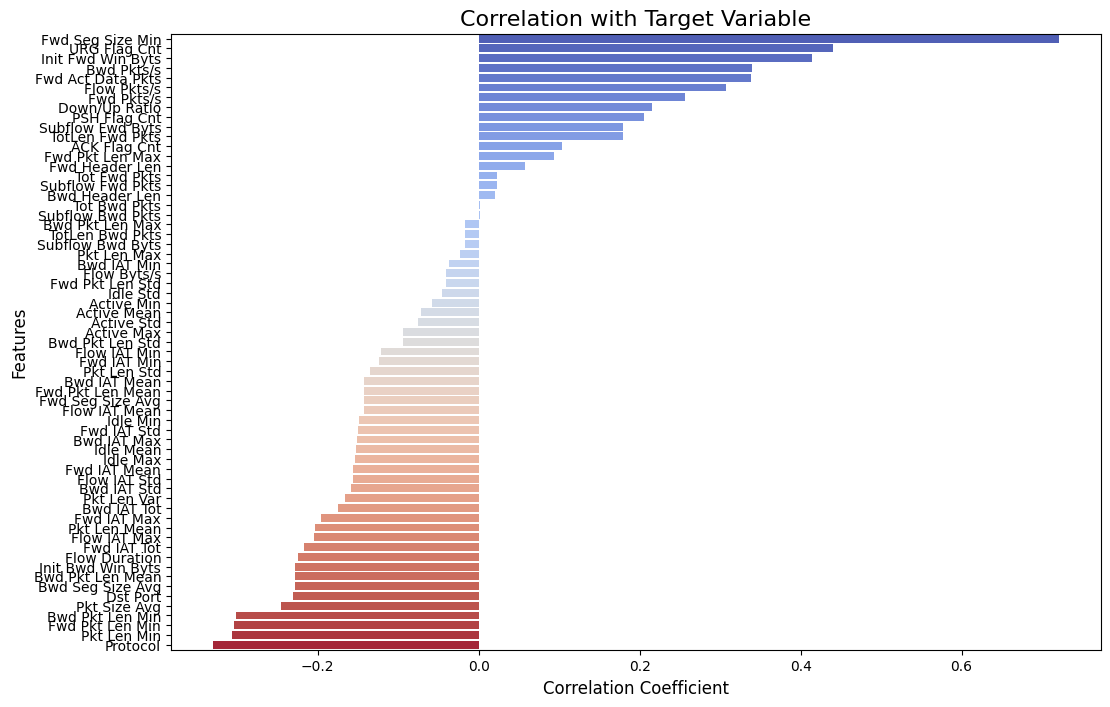

In [291]:
corr_df_with_target = pd.DataFrame({'Feature': clsorrelation_with_y.index, 'Correlation with Target': clsorrelation_with_y.values}).sort_values(by='Correlation with Target', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=corr_df_with_target, x='Correlation with Target', y='Feature', palette='coolwarm')
plt.title('Correlation with Target Variable', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

In [292]:
corr_df_with_target[:4]

,Feature,Correlation with Target
1,Fwd Seg Size Min,0.720549
48,URG Flag Cnt,0.440816
10,Init Fwd Win Byts,0.414639
4,Bwd Pkts/s,0.339083


In [293]:
final_features = corr_df_with_target[(corr_df_with_target['Correlation with Target'] > 0.30) | (corr_df_with_target['Correlation with Target'] < -0.30)]

final_features.reset_index(drop=True)

,Feature,Correlation with Target
0,Fwd Seg Size Min,0.720549
1,URG Flag Cnt,0.440816
2,Init Fwd Win Byts,0.414639
3,Bwd Pkts/s,0.339083
4,Fwd Act Data Pkts,0.338799
5,Flow Pkts/s,0.307682
6,Bwd Pkt Len Min,-0.302101
7,Fwd Pkt Len Min,-0.303946
8,Pkt Len Min,-0.306723
9,Protocol,-0.329945


In [294]:
X_df

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.328151,-0.475197,-0.105628,-0.045803,-0.030222,-0.362027,-0.028287,-0.282446,-0.437753,-0.290530,...,-0.345951,-0.293109,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
1,-0.332278,-0.475197,-0.327201,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,1.508988,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
2,-0.332278,-0.475197,-0.327202,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,1.508988,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
3,-0.330039,1.981179,-0.325096,-0.084933,-0.047587,-0.381570,-0.028455,-0.492120,1.627499,0.027183,...,-0.345951,-1.374367,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
4,-0.332208,-0.475197,-0.327201,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,0.788149,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,-0.330039,1.981179,-0.327152,-0.104498,-0.056269,-0.431001,-0.029109,-0.503156,1.472605,-0.033334,...,-0.541603,-1.374367,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
44996,-0.328151,-0.475197,-0.327198,-0.084933,-0.064952,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,-0.293109,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
44997,-0.332208,-0.475197,-0.327201,-0.104498,-0.056269,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,0.788149,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407
44998,3.158153,-0.475197,-0.327202,-0.065368,-0.064952,-0.473536,-0.029679,-0.639260,-0.437753,-0.779706,...,-0.541603,-0.293109,-0.104024,-0.108959,-0.135299,-0.084171,-0.220343,-0.065558,-0.221491,-0.214407


In [295]:
X_df = X_df.fillna(0)

In [296]:
y

0        0
1        1
2        1
3        0
4        2
        ..
44995    0
44996    0
44997    2
44998    0
44999    0
Length: 45000, dtype: int64

In [297]:
final_X = X_df[final_features['Feature']]
final_y = y

final_X.shape, final_y.shape

((45000, 10), (45000,))

In [298]:
DF_ = pd.concat([final_X, y])
DF_ = DF_.fillna(0)
DF_

,Fwd Seg Size Min,URG Flag Cnt,Init Fwd Win Byts,Bwd Pkts/s,Fwd Act Data Pkts,Flow Pkts/s,Bwd Pkt Len Min,Fwd Pkt Len Min,Pkt Len Min,Protocol,0
0,-0.293109,-0.367796,-0.180608,-0.472030,-0.345951,-0.484555,-0.435096,-0.437753,-0.441752,-0.475197,0.0
1,1.508988,-0.367796,1.267839,-0.284652,-0.541603,-0.303583,-0.435096,-0.437753,-0.441752,-0.475197,0.0
2,1.508988,-0.367796,1.267839,1.401769,-0.541603,1.325187,-0.435096,-0.437753,-0.441752,-0.475197,0.0
3,-1.374367,-0.367796,-0.815519,-0.471899,-0.345951,-0.484429,1.743910,1.627499,1.655981,1.981179,0.0
4,0.788149,2.718895,-0.796766,0.063340,-0.541603,0.032513,-0.435096,-0.437753,-0.441752,-0.475197,0.0
...,...,...,...,...,...,...,...,...,...,...,...
44995,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
44996,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
44997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
44998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [299]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(final_X, final_y, random_state=42, train_size=0.8)

In [300]:
# X_train

In [301]:
import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

def train_local_model_SVC(X_train_SVC, y_train_SVC):
    # smote = SMOTE(random_state=42)
    # X_resampled, y_resampled = smote.fit_resample(X_train_SVC, y_train_SVC)

    # class_weights = compute_class_weight('balanced', classes=np.unique(y_resampled), y=y_resampled)
    # class_weight_dict = dict(zip(np.unique(y_resampled), class_weights))

    svm_SVC = LinearSVC(random_state=42, max_iter=1000, class_weight='balanced')
    svm_SVC.fit(X_train_SVC, y_train_SVC)


    return svm_SVC

def evaluate_model_SVC(model_SVC, X_test_SVC, y_test_SVC):
    y_pred_SVC = model_SVC.predict(X_test_SVC)
    accuracy_SVC = accuracy_score(y_test_SVC, y_pred_SVC)
    report = classification_report(y_test_SVC, y_pred_SVC, output_dict=True)

    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']

    cm = confusion_matrix(y_test_SVC, y_pred_SVC)
    tn, fp, fn, tp = (0, 0, 0, 0)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()

    return accuracy_SVC, precision, recall, f1_score, cm

def federated_averaged_svm_SVC(models_SVC, client_data_sizes, classes_SVC):
    total_data = sum(client_data_sizes)
    weights = [size / total_data for size in client_data_sizes]

    avg_coef_SVC = np.average([model.coef_ for model in models_SVC], axis=0, weights=weights)
    avg_intercept_SVC = np.average([model.intercept_ for model in models_SVC], axis=0, weights=weights)

    avg_model_SVC = LinearSVC(random_state=42, max_iter=10000)
    avg_model_SVC.coef_ = avg_coef_SVC
    avg_model_SVC.intercept_ = avg_intercept_SVC
    avg_model_SVC.classes_ = classes_SVC

    return avg_model_SVC

def federated_learning_SVC(models_SVC, client_data_sizes, X_test_SVC, y_test_SVC, classes_SVC):
    global_model_SVC = federated_averaged_svm_SVC(models_SVC, client_data_sizes, classes_SVC)
    accuracy_SVC, precision, recall, f1_score, confusion_mat = evaluate_model_SVC(global_model_SVC, X_test_SVC, y_test_SVC)

    return {
        'Accuracy': accuracy_SVC,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score,
        'Confusion Matrix': confusion_mat
    }

In [302]:
model = train_local_model_SVC(X_train, y_train)
accuracy_SVC, precision, recall, f1_score, confusion_mat = evaluate_model_SVC(model, X_test, y_test)
print(f"Accuracy: {accuracy_SVC:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print("Confusion Matrix:")
print(confusion_mat)
print("-" * 40)

Accuracy: 0.9981
Precision: 0.9981
Recall: 0.9981
F1 Score: 0.9981
Confusion Matrix:
[[5748    7   10]
 [   0 1636    0]
 [   0    0 1599]]
----------------------------------------


In [311]:
sadf = pd.concat([final_X, final_y], axis=1)

sadf.rename(columns={sadf.columns[-1]: 'label'}, inplace=True)

df_for_api = sadf.to_csv('df_for_api.csv')